<a href="https://colab.research.google.com/github/phenomenaldatalab/Foundations-of-AI-for-Business/blob/main/Exercises1_The_General_Intelligence_Problem_Credit_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1. Reinforcement Paradigm: T-maze and Labyrinth (17 min)


## 1.1 T-maze coding activity (17 min)
**Step 1: Setting up the Mouse & Environment (2 min)**


*   **Locate (1) in the code:** This is the mouse's initial belief. The default ```self.left_probability``` is 0.5 (50% chance to go left). Try changing this value later to see how a biased mouse learns!
*   **Locate num_trials = 1000 at the bottom:** This is how many days the mouse explores. Keep this in mind, as you will modify it in Step 4.

**Step 2: Fill in the Learning Logic (8 min)**

The mouse updates its strategy based on success or failure. You need to delete the underscores ```(___)``` and complete the code for blocks (2), (3), and (4) using the cheat sheet below.

💡 **Cheat Sheet: Variables & Operators**
*   ```self.left_probability``` : The mouse's current probability of going left.
*   ```self.learning_rate``` : How fast the mouse changes its mind.
*   ```+=``` : Increase the value (Add).
*   ```-=``` : Decrease the value (Subtract).
*   ```==``` : Check if two values are exactly the same.

*   Block (2): The mouse chose 'right' and found the cheese. Therefore, the probability of going 'left' must decrease.
*   Block (3): The mouse chose 'right' but failed. This means the cheese is likely on the left! So, the probability of going 'left' must increase.
*   Block (4): How do we define a success? It's a success if the mouse's choice exactly matches the cheese's location.

**Step 3: Observe and Analyze (2 min)**

*   Run the code and look at the generated plot.(Click the ```Run all``` button at the top or Play button of the code block)
*   Observe where the mouse's probability eventually settles. Compare it with the actual environment rule (the red dotted line representing the true probability of the cheese being on the left, 0.7).
*   Analyze the lines. How do different Learning Rates (LR) affect the mouse's learning curve? Which LR reaches the red dotted line fastest, and which one fluctuates the most?

**Step 4: Experiment!(5 min)**
Now it's your turn to play around with the variables:

*   Change the ```num_trials``` (e.g., to 100 or 5000) to see if the mouse has enough time to learn.
*   Change the ```left_cheese_probability``` (Environment rule) or the ```learning_rates``` list to see how the agent adapts to new situations.

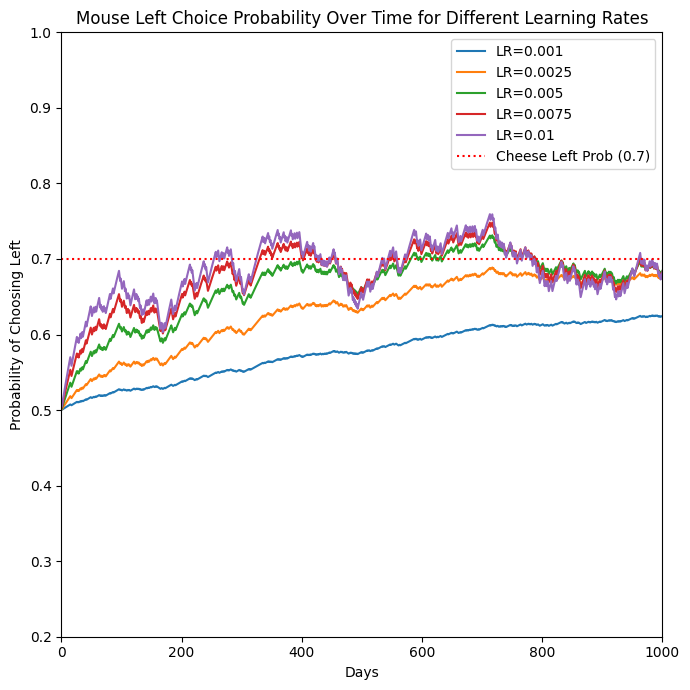

In [ ]:
import random
import matplotlib.pyplot as plt

# Class for the T-Maze environment
class TMaze:
    def __init__(self, left_probability):
        self.left_probability = left_probability

    # Place cheese on the left or right side
    def place_cheese(self):
        return 'left' if random.random() < self.left_probability else 'right'

# Class for the mouse's behavior
class Mouse:
    def __init__(self, learning_rate = 0.0025):

        ##########################################################################################
        ### (1) Initialize the mouse's starting probability of going left (hint: default is 0.5) ###
        ##########################################################################################
        self.left_probability = 0.5  # (1)
        self.learning_rate = learning_rate

    # Mouse chooses which direction to go
    def choose_direction(self):
        return 'left' if random.random() < self.left_probability else 'right'

    # Update the mouse's policy based on success or failure
    def update_policy(self, choice, success):
        if success:
            if choice == 'left':
                self.left_probability += self.learning_rate * (1 - self.left_probability)
            else:
                #################################################################################
                ### (2) Update the left probability when the mouse chooses 'right' and succeeds ###
                #################################################################################
                self.left_probability = ___ # (2)
                # Answer for (2): self.left_probability -= self.learning_rate * self.left_probability

        else:
            if choice == 'left':
                self.left_probability -= self.learning_rate * self.left_probability
            else:
                ##############################################################################
                ### (3) Update the left probability when the mouse chooses 'right' and fails ###
                ##############################################################################
                self.left_probability = ___  # (3)
                # Answer for (3): self.left_probability += self.learning_rate * (1 - self.left_probability)

# Run the simulation
def run_simulation(t_maze, mouse, num_trials = 1000, seed = None):
    if seed is not None:
        random.seed(seed)

    performances = []
    left_probabilities = []
    for _ in range(num_trials):
        mouse_choice = mouse.choose_direction()
        cheese_location = t_maze.place_cheese()

        #####################################################################
        ### (4) Determine if the mouse's choice matches the cheese location ###
        #####################################################################
        success = ___ # (4)
        # Answer for (4): success = mouse_choice == cheese_location

        mouse.update_policy(mouse_choice, success)
        performances.append(1 if success else 0)
        left_probabilities.append(mouse.left_probability)

    return performances, left_probabilities

# Plot the results
def plot_results(left_probabilities_dict, left_cheese_probability = 0.7):
    days = list(range(1, 1001))

    plt.figure(figsize = (7, 7))
    for lr, left_probabilities in left_probabilities_dict.items():
        plt.plot(days, left_probabilities, label=f'LR={lr}')

    plt.xlabel('Days')
    plt.ylabel('Probability of Choosing Left')
    plt.title('Mouse Left Choice Probability Over Time for Different Learning Rates')
    plt.ylim(0.2, 1)
    plt.xlim(0, 1000)

    plt.axhline(y=left_cheese_probability, color='red', linestyle='dotted', label='Cheese Left Prob (0.7)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Setup
left_cheese_probability = 0.7
learning_rates = [0.001, 0.0025, 0.005, 0.0075, 0.01]
    ############################################################################
    #######For step 4, you can change the list of learning_rate here#############
    ############################################################################
left_probabilities_dict = {}

# Run simulations for each learning rate
seed_value = 42
for lr in learning_rates:
    t_maze = TMaze(left_cheese_probability)
    mouse = Mouse(learning_rate=lr)
    _, left_probabilities = run_simulation(t_maze, mouse, num_trials=1000, seed=seed_value)
    ############################################################################
    ############For step 4, you can change the num_trials here##################
    ############################################################################
    left_probabilities_dict[lr] = left_probabilities

# Plot results
plot_results(left_probabilities_dict, left_cheese_probability)


## 1.2 Labyrinth coding activity (3 min)


### Question 1: Run the code and then observe the relationship between labyrinth size and time required to execute simulation. Examine the exponential-fit curve (2 min)

Running experiments: 100%|██████████| 7/7 [00:40<00:00,  5.77s/it]


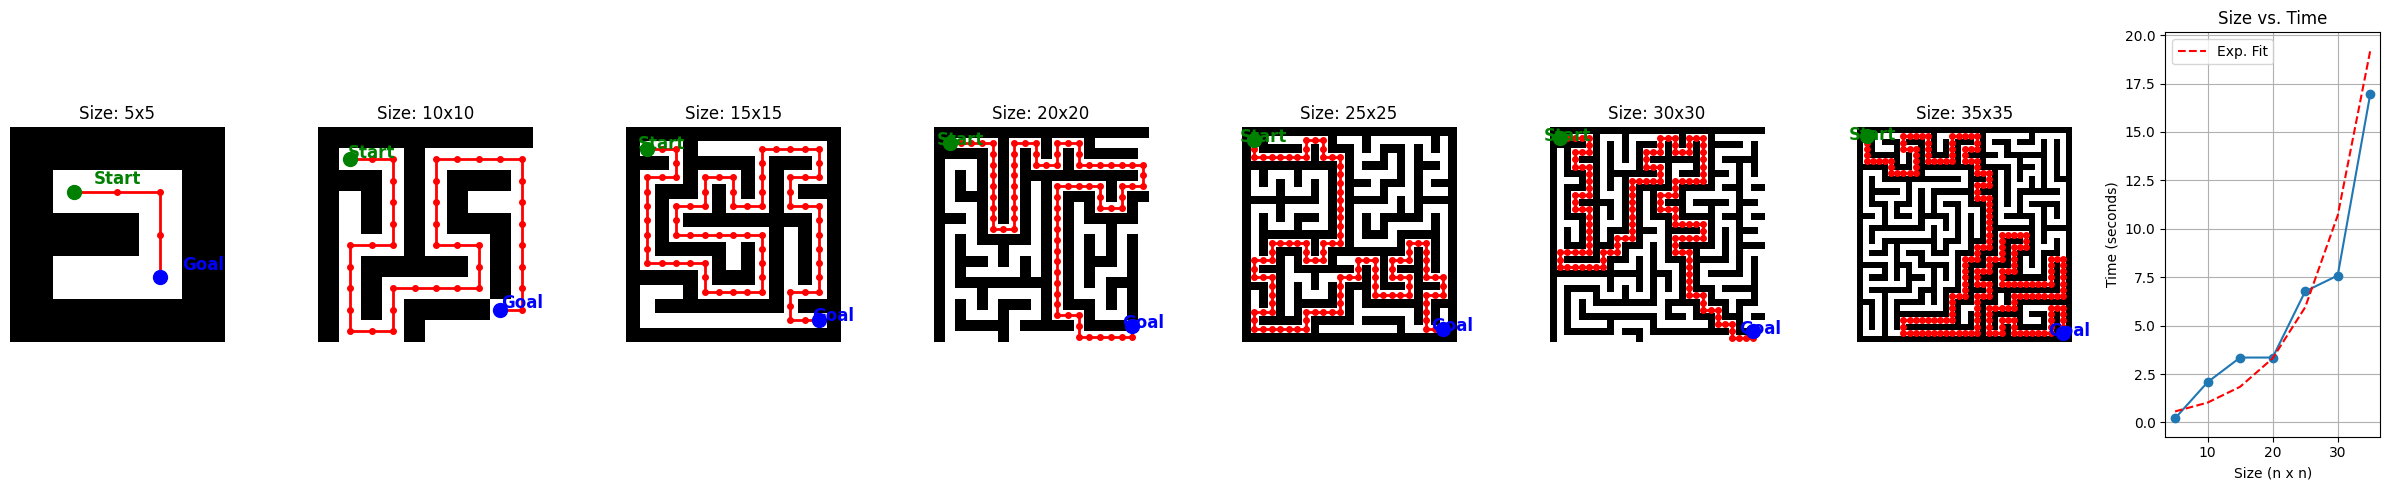

Fitted exponential function: y = 0.3183 * e^(0.1171x)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

class Labyrinth:
    def __init__(self, size):
        self.size = size
        self.labyrinth = np.ones((size, size))
        self.start = (1, 1)
        self.goal = (size-2, size-2)
        self.generate_labyrinth()

    def generate_labyrinth(self):
        self.labyrinth = np.ones((self.size, self.size))

        def carve_path(x, y):
            self.labyrinth[y][x] = 0
            directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
            np.random.shuffle(directions)
            for dx, dy in directions:
                nx, ny = x + dx*2, y + dy*2
                if 0 <= nx < self.size and 0 <= ny < self.size and self.labyrinth[ny][nx] == 1:
                    self.labyrinth[y+dy][x+dx] = 0
                    carve_path(nx, ny)

        carve_path(1, 1)
        self.labyrinth[self.start] = 0
        self.labyrinth[self.goal] = 0

    def is_valid_move(self, state):
        return 0 <= state[0] < self.size and 0 <= state[1] < self.size and self.labyrinth[state] == 0

class QLearningAgent:
    def __init__(self, labyrinth):
        self.labyrinth = labyrinth
        self.q_table = np.zeros((labyrinth.size, labyrinth.size, 4))
        self.epsilon = 0.1
        self.alpha = 0.1
        self.gamma = 0.99

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(4)
        return np.argmax(self.q_table[state])

    def update_q_table(self, state, action, next_state, reward):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state + (best_next_action,)]
        td_error = td_target - self.q_table[state + (action,)]
        self.q_table[state + (action,)] += self.alpha * td_error

def train_agent(labyrinth, agent, episodes):
    actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # up, right, down, left
    for _ in range(episodes):
        state = labyrinth.start
        while state != labyrinth.goal:
            action = agent.get_action(state)
            next_state = (state[0] + actions[action][0], state[1] + actions[action][1])
            if labyrinth.is_valid_move(next_state):
                reward = 1 if next_state == labyrinth.goal else -0.01
                agent.update_q_table(state, action, next_state, reward)
                state = next_state
            else:
                reward = -1
                agent.update_q_table(state, action, state, reward)

# Run experiments for different sizes
sizes = range(5, 36, 5)
episodes = 5000

# Run the size vs. time experiment
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

def visualize_path(labyrinth, agent, ax, size):
    state = labyrinth.start
    path = [state]
    actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # up, right, down, left
    while state != labyrinth.goal:
        action = np.argmax(agent.q_table[state])
        next_state = (state[0] + actions[action][0], state[1] + actions[action][1])
        if labyrinth.is_valid_move(next_state):
            state = next_state
            path.append(state)
        else:
            break

    ax.imshow(labyrinth.labyrinth, cmap='binary')
    path = np.array(path)
    ax.plot(path[:, 1], path[:, 0], color='red', linewidth=2, marker='o', markersize=4)
    ax.set_title(f"Size: {size}x{size}")
    ax.axis('off')

def run_experiments_and_plot():
    sizes = range(5, 36, 5)
    episodes = 5000
    times = []
    fig, axs = plt.subplots(1, 8, figsize=(24, 5))

    for i, size in enumerate(tqdm(sizes, desc="Running experiments")):
        labyrinth = Labyrinth(size)
        agent = QLearningAgent(labyrinth)

        start_time = time.time()
        train_agent(labyrinth, agent, episodes)
        end_time = time.time()

        times.append(end_time - start_time)

        visualize_path(labyrinth, agent, axs[i], size)

    # Plot size vs. time
    ax_time = axs[-1]
    ax_time.plot(sizes, times, marker='o')
    ax_time.set_title("Size vs. Time")
    ax_time.set_xlabel("Size (n x n)")
    ax_time.set_ylabel("Time (seconds)")
    ax_time.grid(True)

    coeffs = np.polyfit(sizes, np.log(times), 1)
    poly = np.poly1d(coeffs)
    ax_time.plot(sizes, np.exp(poly(sizes)), 'r--', label='Exp. Fit')
    ax_time.legend()

    plt.tight_layout()
    plt.show()

    a, b = coeffs
    print(f"Fitted exponential function: y = {np.exp(b):.4f} * e^({a:.4f}x)")
def visualize_path(labyrinth, agent, ax, size):
    state = labyrinth.start
    path = [state]
    actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # up, right, down, left
    while state != labyrinth.goal:
        action = np.argmax(agent.q_table[state])
        next_state = (state[0] + actions[action][0], state[1] + actions[action][1])
        if labyrinth.is_valid_move(next_state):
            state = next_state
            path.append(state)
        else:
            break

    # Plot the labyrinth
    ax.imshow(labyrinth.labyrinth, cmap='binary')

    # Convert path to numpy array for easier plotting
    path = np.array(path)

    # Plot the path with red color
    ax.plot(path[:, 1], path[:, 0], color='red', linewidth=2, marker='o', markersize=4)

    # Mark the start and goal positions with colored dots
    ax.scatter(labyrinth.start[1], labyrinth.start[0], color='green', s=100, label='Start', zorder=3)
    ax.scatter(labyrinth.goal[1], labyrinth.goal[0], color='blue', s=100, label='Goal', zorder=3)

    # Add text labels for start and goal, slightly offset to avoid overlap
    ax.text(labyrinth.start[1] + 1, labyrinth.start[0] - 0.3, 'Start', color='green', fontsize=12, fontweight='bold',
            ha='center', va='center')
    ax.text(labyrinth.goal[1] + 1, labyrinth.goal[0] - 0.3, 'Goal', color='blue', fontsize=12, fontweight='bold',
            ha='center', va='center')

    # Set title and turn off axis
    ax.set_title(f"Size: {size}x{size}")
    ax.axis('off')


# Run the experiments and plot the results
run_experiments_and_plot()

### Question 2: Change the size of the maze to 200*200. Experiment on 200 x 200 size maze as an illustration of curse of dimensionality (3 min)


- Tip: Don't worry if you cannot get the result. The labyrinth just too complex. You can stop running after 2 minutes.

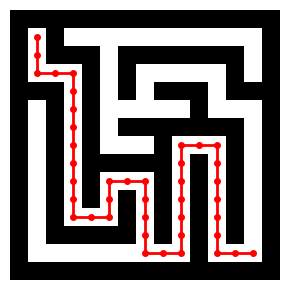

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
sys.setrecursionlimit(10000)  # Increase recursion limit


class Labyrinth:
    def __init__(self, size):
        self.size = size
        self.labyrinth = np.ones((size, size))
        self.start = (1, 1)
        self.goal = (size-2, size-2)
        self.generate_labyrinth()

    def generate_labyrinth(self):
        self.labyrinth = np.ones((self.size, self.size))

        def carve_path(x, y):
            self.labyrinth[y][x] = 0
            directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
            np.random.shuffle(directions)
            for dx, dy in directions:
                nx, ny = x + dx*2, y + dy*2
                if 0 <= nx < self.size and 0 <= ny < self.size and self.labyrinth[ny][nx] == 1:
                    self.labyrinth[y+dy][x+dx] = 0
                    carve_path(nx, ny)

        carve_path(1, 1)
        self.labyrinth[self.start] = 0
        self.labyrinth[self.goal] = 0

    def is_valid_move(self, state):
        return 0 <= state[0] < self.size and 0 <= state[1] < self.size and self.labyrinth[state] == 0

class QLearningAgent:
    def __init__(self, labyrinth):
        self.labyrinth = labyrinth
        self.q_table = np.zeros((labyrinth.size, labyrinth.size, 4))
        self.epsilon = 0.1
        self.alpha = 0.1
        self.gamma = 0.99

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(4)
        return np.argmax(self.q_table[state])

    def update_q_table(self, state, action, next_state, reward):
        best_next_action = np.argmax(self.q_table[next_state])
        td_target = reward + self.gamma * self.q_table[next_state + (best_next_action,)]
        td_error = td_target - self.q_table[state + (action,)]
        self.q_table[state + (action,)] += self.alpha * td_error

def train_agent(labyrinth, agent, episodes):
    actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # up, right, down, left
    for _ in range(episodes):
        state = labyrinth.start
        while state != labyrinth.goal:
            action = agent.get_action(state)
            next_state = (state[0] + actions[action][0], state[1] + actions[action][1])
            if labyrinth.is_valid_move(next_state):
                reward = 1 if next_state == labyrinth.goal else -0.01
                agent.update_q_table(state, action, next_state, reward)
                state = next_state
            else:
                reward = -1
                agent.update_q_table(state, action, state, reward)

def visualize_path(labyrinth, agent, ax):
    state = labyrinth.start
    path = [state]
    actions = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # up, right, down, left
    while state != labyrinth.goal:
        action = np.argmax(agent.q_table[state])
        next_state = (state[0] + actions[action][0], state[1] + actions[action][1])
        if labyrinth.is_valid_move(next_state):
            state = next_state
            path.append(state)
        else:
            break

    ax.imshow(labyrinth.labyrinth, cmap='binary')
    path = np.array(path)
    ax.plot(path[:, 1], path[:, 0], color='red', linewidth=2, marker='o', markersize=4)
    ax.axis('off')

#################################################################################
# Run the experiment for a 200*200 labyrinth
#################################################################################
size = 15 #change the size to 200
episodes = 5000
fig, ax = plt.subplots(figsize=(3, 3))
labyrinth = Labyrinth(size)
agent = QLearningAgent(labyrinth)
# Train the agent
train_agent(labyrinth, agent, episodes)

# Visualize the path
visualize_path(labyrinth, agent, ax)

plt.tight_layout()
plt.show()


# Exercise 2: Blocks World (15 minutes)

## Objective
To help students understand the paradigm of learning to assign credit in a society via Minsky's famous Blocks World example. Students will explore how intelligent systems solve problems by coordinating diverse specialized agents.

### **Task 1: Simulating the Blocks World (Solo "Society of Mind")**

**Setup (1 min)**
* **Materials:** Physical blocks of varying sizes and colors (e.g., LEGO, wooden cubes), paper, and a pen.
* **Scenario:** In Marvin Minsky's "Society of Mind," intelligence emerges from the coordination of many simple, specialized agents.  You will act as the "Manager Agent" (`BUILDER`), who must coordinate a society of "Sub-Agents" to achieve a goal. You will also learn how to assign credit or blame when things go right or wrong.

---

**Activity (8 mins)**

**Phase 1: Meet Your Society of Agents (2 mins)**
You cannot move blocks directly. You can only "call" the following specialized Sub-Agents. Write them down as your cheat sheet:
* `FIND(Block)`: Locates a specific block.
* `CLEAR(Block)`: Removes any blocks sitting on top of the target block.
* `GRASP(Block)`: Picks up the block (fails if the block is not cleared).
* `MOVE(Target)`: Moves the grasped block to a new location (e.g., Table, or on top of Block A).
* `RELEASE()`: Lets go of the block.

**Phase 2: Coordination & Planning (3 mins)**
* **Goal:** Build a simple structure (e.g., "Stack the Red block on top of the Blue block, and the Yellow block on top of the Red block").
* **Task:** As the Manager, write down the exact sequence of Sub-Agents you need to call to achieve this goal.
* *Example start:* 1. `FIND(Blue)` -> 2. `GRASP(Blue)` -> 3. `MOVE(Table)` -> 4. `RELEASE()` ...

**Phase 3: Execution & Credit Assignment (3 mins)**
* Now, act as the physical robot blindly following your written script step by step.
* **Assigning Blame (Failure):** Did you try to `GRASP(Red)` while the Yellow block was still on top of it? The system crashes! Which agent gets the blame? The Manager (you) gets the blame for failing to call the `CLEAR(Red)` agent first. Add a penalty mark to that step and rewrite the script.
* **Assigning Credit (Success):** If the structure is successfully built, trace back your steps. Which agents contributed the most critical moves? Give a "check mark" (credit) to the sequence of agents that successfully placed the final block.


### **Part 3. Individual Reflection: Comparing Reinforcement Learning and Learning in a Society Paradigms (15 min)**

Take some time to individually reflect on the questions below. Think deeply about what you've learned from both the T-maze simulation and the Blocks World activity.


Write down your thoughts, conclusions, and any 'aha!' moments in your notebook (or you can add a new Colab text cell below to type them out).

1. How does the labyrinth simulation relate to real-world organizational decision-making? (5 min)
2. What were the challenges involved in assigning credit? (2 mins) And What sort of knowledge was needed to build the tower? What knowledge might you need or want to keep in memory if you were to build another similar tower? (2 mins)
3. What are the limitations of either paradigm in terms of the use of AI in organizations to enhance their ability to learn to assign credit (i.e., to be intelligent)? (5 min)